In [69]:
import numpy as np
import scipy
from matplotlib import pyplot as plt
import sklearn

Text(0.5, 0, 'Black hole mass $[M_\\odot]$')

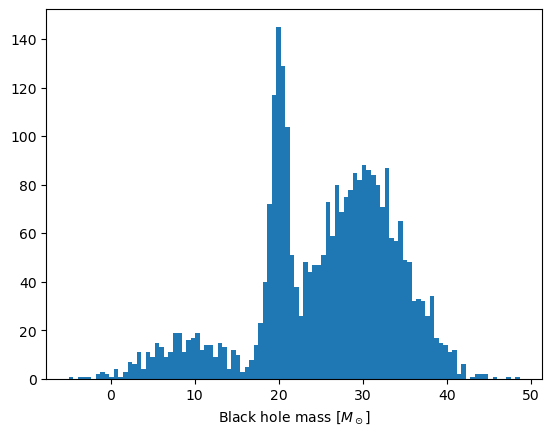

In [74]:
#loading the data
data = np.load('formationchannels.npy')
plt.hist(data, 100) #preliminary histogram plot
plt.xlabel('Black hole mass $[M_\odot]$')


Text(0, 0.5, 'AIC')

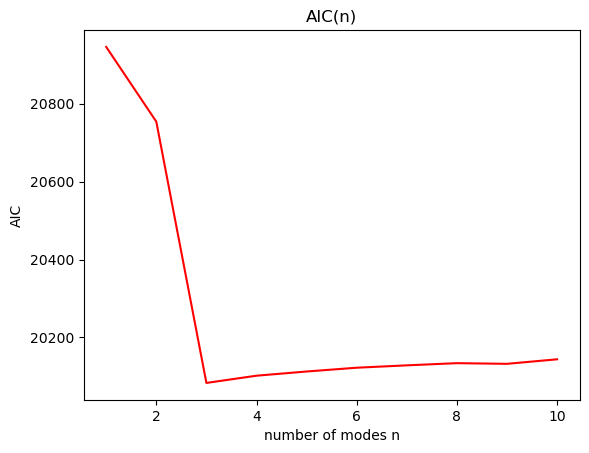

In [71]:
import sklearn.mixture

aic = []

#fitting the data with a varible number of gaussians (#modes)
for n in range(1, 11):
    
    trial_model = sklearn.mixture.GaussianMixture(n)
    trial_model.fit(data)
    aic.append(trial_model.aic(data))


#plotting the AIC as a function of the number of modes
x_vals = np.linspace(1, 10, 10)
plt.plot(x_vals, aic, c='red')
plt.title('AIC(n)')
plt.xlabel('number of modes n')
plt.ylabel('AIC')

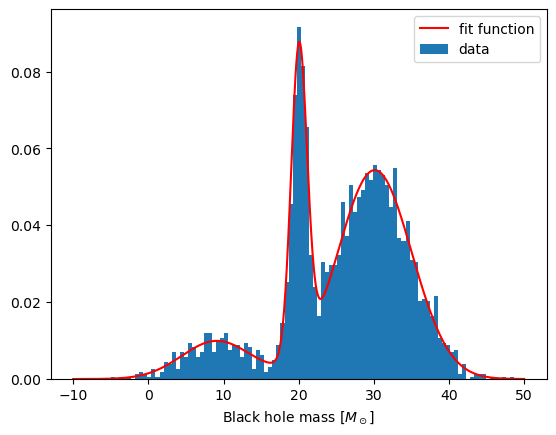

In [78]:
import sklearn.mixture

#fitting the data with a sum of n gaussians, with n minimizing the AIC value
n_modes = np.argsort(aic)[0]+1
model = sklearn.mixture.GaussianMixture(3)
model.fit(data)

x_grid = np.linspace(-10, 50, 1000)
fit_function = [] #array to store the values of the fitting function
for x in x_grid:
    log_val = model.score_samples(x.reshape(-1, 1))
    fit_function.append(np.exp(log_val))

#plotting the data histogram, along with the fitting function
plt.plot(x_grid, fit_function, c='red', label='fit function')
plt.hist(data, 100, density=True, label='data')
plt.xlabel('Black hole mass $[M_\odot]$')
plt.legend()
